In [17]:

!pip install pandas numpy torch sentence-transformers scikit-learn nltk spacy
!python -m spacy download en_core_web_sm

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


In [18]:

import pandas as pd
import numpy as np
import torch
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import warnings
warnings.filterwarnings('ignore')


In [19]:
  from tqdm.autonotebook import tqdm, trange


In [20]:

# For text processing
import nltk
import spacy
import re
from nltk.tokenize import sent_tokenize, word_tokenize
from typing import List, Dict, Tuple, Union
import hashlib

# Download required NLTK data
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt')

# Load spacy model for better text processing
try:
    nlp = spacy.load("en_core_web_sm")
except OSError:
    print("Spacy model not found. Using NLTK for sentence tokenization.")
    nlp = None


In [21]:
class EnhancedScientificPaperRetrieval:
    def __init__(self, model_name='all-MiniLM-L6-v2', use_gpu=True, extraction_level='sentence'):
        """
        Initialize the Enhanced Scientific Paper Retrieval System with extraction capabilities
        
        Args:
            model_name: Sentence transformer model name
            use_gpu: Whether to use GPU acceleration
            extraction_level: 'sentence', 'paragraph', or 'both'
        """
        # Check GPU availability
        if use_gpu and torch.cuda.is_available():
            self.device = 'cuda'
            print(f"Using GPU: {torch.cuda.get_device_name(0)}")
        else:
            self.device = 'cpu'
            print("Using CPU")
        
        # Load the sentence transformer model
        print(f"Loading model: {model_name}")
        self.model = SentenceTransformer(model_name, device=self.device)
        
        # Storage for papers and embeddings
        self.papers_df = None
        self.extraction_level = extraction_level
        
        # Storage for different levels of text chunks
        self.sentence_data = []  # List of dicts with sentence info
        self.paragraph_data = []  # List of dicts with paragraph info
        self.paper_data = []  # List of dicts with full paper info
        
        # Embeddings for different levels
        self.sentence_embeddings = None
        self.paragraph_embeddings = None
        self.paper_embeddings = None
        
        # Add tracking for unique sentences and paragraphs
        self.sentence_hash_to_idx = {}  # Maps sentence hash to first occurrence index
        self.paragraph_hash_to_idx = {}  # Maps paragraph hash to first occurrence index
        
    def _normalize_text(self, text: str) -> str:
        """Normalize text for duplicate detection"""
        if pd.isna(text) or text == "":
            return ""
        
        text = str(text).strip().lower()
        # Remove extra whitespace and normalize
        text = ' '.join(text.split())
        return text
    
    def _get_text_hash(self, text: str) -> str:
        """Generate a hash for text to detect duplicates"""
        normalized = self._normalize_text(text)
        return hashlib.md5(normalized.encode()).hexdigest()
    
    def _split_into_sentences(self, text: str) -> List[str]:
        """Split text into sentences using NLTK or spaCy"""
        if pd.isna(text) or text == "":
            return []
        
        text = str(text).strip()
        if not text:
            return []
        
        if nlp:
            # Use spaCy for better sentence segmentation
            doc = nlp(text)
            sentences = [sent.text.strip() for sent in doc.sents if sent.text.strip()]
        else:
            # Fallback to NLTK
            sentences = sent_tokenize(text)
            sentences = [s.strip() for s in sentences if s.strip()]
        
        # Filter out very short sentences (less than 10 characters)
        sentences = [s for s in sentences if len(s) > 10]
        return sentences
    
    def _split_into_paragraphs(self, text: str) -> List[str]:
        """Split text into paragraphs"""
        if pd.isna(text) or text == "":
            return []
        
        text = str(text).strip()
        if not text:
            return []
        
        # Split by double newlines or multiple spaces
        paragraphs = re.split(r'\n\s*\n|\r\s*\r', text)
        paragraphs = [p.strip() for p in paragraphs if p.strip()]
        
        # Filter out very short paragraphs (less than 50 characters)
        paragraphs = [p for p in paragraphs if len(p) > 50]
        return paragraphs
    
    def load_papers(self, csv_file_path):
        """
        Load scientific papers from CSV file and create sentence/paragraph chunks with deduplication
        
        Args:
            csv_file_path: Path to CSV file with columns: title, abstract, sections
        """
        print("Loading scientific papers...")
        self.papers_df = pd.read_csv(csv_file_path)
        self.papers_df = self.papers_df.drop_duplicates(
            subset=["title", "abstract", "sections"], 
            keep="first"
        ).reset_index(drop=True)
        
        # Validate required columns
        required_columns = ['title', 'abstract', 'sections']
        missing_columns = [col for col in required_columns if col not in self.papers_df.columns]
        if missing_columns:
            raise ValueError(f"Missing required columns: {missing_columns}")
        
        print("Creating text chunks at different levels...")
        
        # Clear existing data and hash trackers
        self.sentence_data = []
        self.paragraph_data = []
        self.paper_data = []
        self.sentence_hash_to_idx = {}
        self.paragraph_hash_to_idx = {}
        
        # Track statistics
        total_sentences_processed = 0
        unique_sentences_kept = 0
        total_paragraphs_processed = 0
        unique_paragraphs_kept = 0
        
        for paper_idx, row in self.papers_df.iterrows():
            # Handle NaN values
            title = str(row['title']) if pd.notna(row['title']) else ""
            abstract = str(row['abstract']) if pd.notna(row['abstract']) else ""
            sections = str(row['sections']) if pd.notna(row['sections']) else ""
            
            # Store full paper data (these are always unique per paper)
            combined_text = f"Title: {title}. Abstract: {abstract}. Content: {sections}"
            self.paper_data.append({
                'paper_idx': paper_idx,
                'text': combined_text,
                'title': title,
                'abstract': abstract,
                'sections': sections,
                'chunk_type': 'paper',
                'chunk_idx': 0,
                'unique_id': f"paper_{paper_idx}"
            })
            
            # Process each section for sentences and paragraphs
            text_sections = {
                'title': title,
                'abstract': abstract,
                'content': sections
            }
            
            for section_name, section_text in text_sections.items():
                if not section_text or section_text == "nan":
                    continue
                
                # Extract sentences with deduplication
                if self.extraction_level in ['sentence', 'both']:
                    sentences = self._split_into_sentences(section_text)
                    for sent_idx, sentence in enumerate(sentences):
                        total_sentences_processed += 1
                        sentence_hash = self._get_text_hash(sentence)
                        
                        # Check if this sentence already exists
                        if sentence_hash in self.sentence_hash_to_idx:
                            # Skip duplicate sentence
                            continue
                        
                        # Add unique sentence
                        unique_sentences_kept += 1
                        current_idx = len(self.sentence_data)
                        self.sentence_hash_to_idx[sentence_hash] = current_idx
                        
                        self.sentence_data.append({
                            'paper_idx': paper_idx,
                            'text': sentence,
                            'title': title,
                            'abstract': abstract[:200] + "..." if len(abstract) > 200 else abstract,
                            'section_name': section_name,
                            'chunk_type': 'sentence',
                            'chunk_idx': sent_idx,
                            'unique_id': f"sent_{current_idx}",
                            'text_hash': sentence_hash,
                            'full_section': section_text[:500] + "..." if len(section_text) > 500 else section_text
                        })
                
                # Extract paragraphs with deduplication
                if self.extraction_level in ['paragraph', 'both']:
                    paragraphs = self._split_into_paragraphs(section_text)
                    for para_idx, paragraph in enumerate(paragraphs):
                        total_paragraphs_processed += 1
                        paragraph_hash = self._get_text_hash(paragraph)
                        
                        # Check if this paragraph already exists
                        if paragraph_hash in self.paragraph_hash_to_idx:
                            # Skip duplicate paragraph
                            continue
                        
                        # Add unique paragraph
                        unique_paragraphs_kept += 1
                        current_idx = len(self.paragraph_data)
                        self.paragraph_hash_to_idx[paragraph_hash] = current_idx
                        
                        self.paragraph_data.append({
                            'paper_idx': paper_idx,
                            'text': paragraph,
                            'title': title,
                            'abstract': abstract[:200] + "..." if len(abstract) > 200 else abstract,
                            'section_name': section_name,
                            'chunk_type': 'paragraph',
                            'chunk_idx': para_idx,
                            'unique_id': f"para_{current_idx}",
                            'text_hash': paragraph_hash,
                            'full_section': section_text[:500] + "..." if len(section_text) > 500 else section_text
                        })
        
        print(f"Created chunks:")
        print(f"  - Papers: {len(self.paper_data)}")
        print(f"  - Sentences: {unique_sentences_kept} unique (from {total_sentences_processed} total)")
        print(f"  - Paragraphs: {unique_paragraphs_kept} unique (from {total_paragraphs_processed} total)")
        
        if total_sentences_processed > 0:
            dup_sent_pct = ((total_sentences_processed - unique_sentences_kept) / total_sentences_processed) * 100
            print(f"  - Sentence deduplication: {dup_sent_pct:.1f}% duplicates removed")
        
        if total_paragraphs_processed > 0:
            dup_para_pct = ((total_paragraphs_processed - unique_paragraphs_kept) / total_paragraphs_processed) * 100
            print(f"  - Paragraph deduplication: {dup_para_pct:.1f}% duplicates removed")
        
        return self.papers_df
    
    def create_embeddings(self):
        """Create embeddings for sentences, paragraphs, and/or full papers"""
        print("Creating embeddings...")
        
        batch_size = 32
        
        # Create sentence embeddings
        if self.extraction_level in ['sentence', 'both'] and self.sentence_data:
            print(f"Creating embeddings for {len(self.sentence_data)} unique sentences...")
            sentence_texts = [item['text'] for item in self.sentence_data]
            self.sentence_embeddings = self.model.encode(
                sentence_texts,
                batch_size=batch_size,
                show_progress_bar=True,
                convert_to_numpy=True
            )
            print(f"Sentence embeddings shape: {self.sentence_embeddings.shape}")
        
        # Create paragraph embeddings
        if self.extraction_level in ['paragraph', 'both'] and self.paragraph_data:
            print(f"Creating embeddings for {len(self.paragraph_data)} unique paragraphs...")
            paragraph_texts = [item['text'] for item in self.paragraph_data]
            self.paragraph_embeddings = self.model.encode(
                paragraph_texts,
                batch_size=batch_size,
                show_progress_bar=True,
                convert_to_numpy=True
            )
            print(f"Paragraph embeddings shape: {self.paragraph_embeddings.shape}")
        
        # Create paper embeddings (always create for comparison)
        if self.paper_data:
            print(f"Creating embeddings for {len(self.paper_data)} papers...")
            paper_texts = [item['text'] for item in self.paper_data]
            self.paper_embeddings = self.model.encode(
                paper_texts,
                batch_size=batch_size,
                show_progress_bar=True,
                convert_to_numpy=True
            )
            print(f"Paper embeddings shape: {self.paper_embeddings.shape}")
    
    def search_relevant_chunks(self, query: str, top_k: int = 10, chunk_type: str = 'auto') -> List[Dict]:
        """
        Find the most relevant text chunks for a query
        
        Args:
            query: Query string
            top_k: Number of top results to return
            chunk_type: 'sentence', 'paragraph', 'paper', or 'auto'
        
        Returns:
            List of dictionaries with chunk info and similarity scores
        """
        # Determine which embeddings to use
        if chunk_type == 'auto':
            chunk_type = self.extraction_level if self.extraction_level != 'both' else 'sentence'
        
        if chunk_type == 'sentence' and self.sentence_embeddings is not None:
            embeddings = self.sentence_embeddings
            data = self.sentence_data
        elif chunk_type == 'paragraph' and self.paragraph_embeddings is not None:
            embeddings = self.paragraph_embeddings
            data = self.paragraph_data
        elif chunk_type == 'paper' and self.paper_embeddings is not None:
            embeddings = self.paper_embeddings
            data = self.paper_data
        else:
            raise ValueError(f"No embeddings available for chunk_type: {chunk_type}")
        
        # Create query embedding
        query_embedding = self.model.encode([query], convert_to_numpy=True)
        
        # Calculate similarities
        similarities = cosine_similarity(query_embedding, embeddings)[0]
        
        # Get top-k results
        top_indices = np.argsort(similarities)[::-1][:top_k]
        
        results = []
        for idx in top_indices:
            chunk = data[idx].copy()
            chunk['similarity_score'] = float(similarities[idx])
            chunk['rank'] = len(results) + 1
            results.append(chunk)
        
        return results
    
    def search_multi_level(self, query: str, top_k: int = 10) -> Dict[str, List[Dict]]:
        """
        Search at multiple levels (sentence, paragraph, paper) and return combined results
        """
        results = {}
        
        if self.sentence_embeddings is not None:
            results['sentences'] = self.search_relevant_chunks(query, top_k, 'sentence')
        
        if self.paragraph_embeddings is not None:
            results['paragraphs'] = self.search_relevant_chunks(query, top_k, 'paragraph')
        
        if self.paper_embeddings is not None:
            results['papers'] = self.search_relevant_chunks(query, top_k, 'paper')
        
        return results
    
    def get_context_for_chunk(self, chunk_result: Dict, context_window: int = 2) -> Dict:
        """
        Get surrounding context for a sentence or paragraph chunk
        
        Args:
            chunk_result: Result dictionary from search
            context_window: Number of sentences/paragraphs to include before and after
        """
        paper_idx = chunk_result['paper_idx']
        section_name = chunk_result['section_name']
        chunk_idx = chunk_result['chunk_idx']
        chunk_type = chunk_result['chunk_type']
        
        # Get the full section text
        paper_row = self.papers_df.iloc[paper_idx]
        if section_name == 'title':
            full_text = str(paper_row['title'])
        elif section_name == 'abstract':
            full_text = str(paper_row['abstract'])
        else:
            full_text = str(paper_row['sections'])
        
        context_info = {
            'target_chunk': chunk_result['text'],
            'full_section': full_text,
            'paper_title': paper_row['title'],
            'section_name': section_name,
            'unique_id': chunk_result['unique_id']
        }
        
        if chunk_type == 'sentence':
            # Get surrounding sentences
            sentences = self._split_into_sentences(full_text)
            start_idx = max(0, chunk_idx - context_window)
            end_idx = min(len(sentences), chunk_idx + context_window + 1)
            
            context_info['context_sentences'] = sentences[start_idx:end_idx]
            context_info['target_sentence_idx'] = chunk_idx - start_idx
            
        elif chunk_type == 'paragraph':
            # Get surrounding paragraphs
            paragraphs = self._split_into_paragraphs(full_text)
            start_idx = max(0, chunk_idx - context_window)
            end_idx = min(len(paragraphs), chunk_idx + context_window + 1)
            
            context_info['context_paragraphs'] = paragraphs[start_idx:end_idx]
            context_info['target_paragraph_idx'] = chunk_idx - start_idx
        
        return context_info
    
    def batch_search_with_extraction(self, queries: List[str], labels: List[int] = None, 
                                   top_k: int = 5, chunk_type: str = 'auto') -> Dict:
        """
        Process multiple queries with chunk-level extraction
        """
        all_results = {}
        
        print(f"Processing {len(queries)} queries with {chunk_type} extraction...")
        
        for i, query in enumerate(queries):
            print(f"Processing query {i+1}/{len(queries)}")
            
            if chunk_type == 'multi':
                results = self.search_multi_level(query, top_k)
            else:
                results = self.search_relevant_chunks(query, top_k, chunk_type)
            
            query_data = {
                'query_text': query,
                'results': results
            }
            
            if labels and i < len(labels):
                query_data['relevance_label'] = labels[i]
            
            all_results[f"Query_{i+1}"] = query_data
        
        return all_results
    
    def save_extraction_results(self, results: Dict, output_file: str, chunk_type: str = 'sentence'):
        """Save extraction results to CSV with detailed chunk information"""
        rows = []
        
        for query_key, query_data in results.items():
            query_text = query_data['query_text']
            relevance_label = query_data.get('relevance_label', 'N/A')
            
            # Handle multi-level results
            if isinstance(query_data['results'], dict):
                # Multi-level search results
                for level, level_results in query_data['results'].items():
                    for result in level_results:
                        rows.append({
                            'query_id': query_key,
                            'query_text': query_text,
                            'query_relevance_label': relevance_label,
                            'chunk_level': level,
                            'paper_id': result['paper_idx'],
                            'chunk_idx': result['chunk_idx'],
                            'unique_id': result['unique_id'],
                            'text_hash': result.get('text_hash', 'N/A'),
                            'rank': result['rank'],
                            'similarity_score': result['similarity_score'],
                            'paper_title': result['title'],
                            'section_name': result['section_name'],
                            'chunk_text': result['text'],
                            'chunk_length': len(result['text']),
                            'paper_abstract': result.get('abstract', '')
                        })
            else:
                # Single-level search results
                for result in query_data['results']:
                    rows.append({
                        'query_id': query_key,
                        'query_text': query_text,
                        'query_relevance_label': relevance_label,
                        'chunk_level': result['chunk_type'],
                        'paper_id': result['paper_idx'],
                        'chunk_idx': result['chunk_idx'],
                        'unique_id': result['unique_id'],
                        'text_hash': result.get('text_hash', 'N/A'),
                        'rank': result['rank'],
                        'similarity_score': result['similarity_score'],
                        'paper_title': result['title'],
                        'section_name': result['section_name'],
                        'chunk_text': result['text'],
                        'chunk_length': len(result['text']),
                        'paper_abstract': result.get('abstract', '')
                    })
        
        results_df = pd.DataFrame(rows)
        results_df.to_csv(output_file, index=False)
        print(f"Extraction results saved to: {output_file}")
        return results_df
    
    def get_duplicate_statistics(self):
        """Get statistics about duplicates found"""
        stats = {
            'unique_sentences': len(self.sentence_data),
            'unique_paragraphs': len(self.paragraph_data),
            'sentence_hashes': len(self.sentence_hash_to_idx),
            'paragraph_hashes': len(self.paragraph_hash_to_idx)
        }
        return stats

# Additional utility function for checking duplicates manually
def find_potential_duplicates_in_results(results_df, similarity_threshold=0.95):
    """
    Find potential duplicates in search results based on text similarity
    """
    from sentence_transformers import SentenceTransformer
    from sklearn.metrics.pairwise import cosine_similarity
    
    model = SentenceTransformer('all-MiniLM-L6-v2')
    
    # Get unique texts
    unique_texts = results_df['chunk_text'].unique()
    embeddings = model.encode(unique_texts)
    
    # Calculate pairwise similarities
    similarities = cosine_similarity(embeddings)
    
    duplicates = []
    for i in range(len(similarities)):
        for j in range(i+1, len(similarities)):
            if similarities[i][j] >= similarity_threshold:
                duplicates.append({
                    'text1': unique_texts[i][:100] + "...",
                    'text2': unique_texts[j][:100] + "...",
                    'similarity': similarities[i][j]
                })
    
    return duplicates

In [22]:
retrieval_system = EnhancedScientificPaperRetrieval(
    model_name='all-MiniLM-L6-v2',
    use_gpu=True,
    extraction_level='sentence'  # Will create both sentence and paragraph level extractions
)

Using GPU: GRID V100S-32Q
Loading model: all-MiniLM-L6-v2


In [23]:
papers_file = "extracted_data_full.csv"
papers_df = retrieval_system.load_papers(papers_file)

# Display information about the chunks created
print(f"\nPapers DataFrame shape: {papers_df.shape}")
print(f"Total text chunks created:")
print(f"  - Sentences: {len(retrieval_system.sentence_data)}")
print(f"  - Paragraphs: {len(retrieval_system.paragraph_data)}")
print(f"  - Papers: {len(retrieval_system.paper_data)}")


Loading scientific papers...
Creating text chunks at different levels...
Created chunks:
  - Papers: 106
  - Sentences: 13167 unique (from 13500 total)
  - Paragraphs: 0 unique (from 0 total)
  - Sentence deduplication: 2.5% duplicates removed

Papers DataFrame shape: (106, 5)
Total text chunks created:
  - Sentences: 13167
  - Paragraphs: 0
  - Papers: 106


In [24]:
# ## 6. Create Embeddings for All Chunk Levels

# This creates embeddings for sentences, paragraphs, and papers
retrieval_system.create_embeddings()


Creating embeddings...
Creating embeddings for 13167 unique sentences...


Batches:   0%|          | 0/412 [00:00<?, ?it/s]

Sentence embeddings shape: (13167, 384)
Creating embeddings for 106 papers...


Batches:   0%|          | 0/4 [00:00<?, ?it/s]

Paper embeddings shape: (106, 384)


In [25]:
print(retrieval_system.sentence_embeddings[0])       # first embedding
print(len(retrieval_system.sentence_embeddings[0])) 

[ 2.31356844e-02  5.66806793e-02  1.03319354e-01 -5.73694594e-02
  6.46631718e-02 -7.08001256e-02 -9.51581728e-03 -1.38564324e-02
 -5.63341044e-02  7.22668767e-02 -2.11186986e-02 -1.45593628e-01
  3.97884212e-02 -2.41086329e-03 -6.58832083e-04  1.59745924e-02
 -7.63057321e-02 -2.40159314e-02 -2.45144702e-02 -7.90999010e-02
  6.23741560e-02  5.35263307e-02  1.99937653e-02 -7.09375665e-02
  2.58038342e-02  1.03608901e-02  2.03199685e-02 -1.14544202e-03
  1.67716648e-02 -2.23615561e-02 -8.96988288e-02  5.96093088e-02
  2.17772778e-02  4.26065624e-02 -3.46035361e-02  5.12288176e-02
 -1.24395631e-01  4.72683609e-02  6.08615158e-03  4.22354750e-02
  8.24607536e-02 -3.67048346e-02  3.70959938e-03 -8.32960010e-02
 -8.50815605e-03  7.34141394e-02  2.40640691e-03  6.99495757e-03
 -3.36523838e-02  3.26904655e-02  6.38852268e-02  4.54208702e-02
 -5.34716435e-03 -2.07881145e-02 -4.24631834e-02  1.36328917e-02
  9.38876998e-03  8.00317153e-03  1.65555291e-02 -2.69551519e-02
  3.36463340e-02  6.44691

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

def plot_sentence_vectors_as_arrows(
    retrieval_system,
    indices=None,         # e.g., [0, 3, 7, 12]; if None, it picks the first max_vectors
    max_vectors=8,        # how many arrows to draw
    normalize=True,       # normalize each 2D vector to unit length (nice for direction-only view)
    annotate=True,        # add tiny text labels (start of the sentence)
    which="sentence"      # "sentence" | "paragraph" | "paper"
):
    # 1) pick the right embedding matrix + metadata list
    if which == "sentence":
        embs = retrieval_system.sentence_embeddings
        meta = retrieval_system.sentence_data
    elif which == "paragraph":
        embs = retrieval_system.paragraph_embeddings
        meta = retrieval_system.paragraph_data
    elif which == "paper":
        embs = retrieval_system.paper_embeddings
        meta = retrieval_system.paper_data
    else:
        raise ValueError("which must be 'sentence', 'paragraph', or 'paper'")

    if embs is None or len(embs) == 0:
        raise ValueError(f"No embeddings available for {which}. Did you call create_embeddings()?")

    # 2) choose which rows to visualize
    if indices is None:
        n = min(max_vectors, len(embs))
        indices = list(range(n))
    else:
        indices = [i for i in indices if 0 <= i < len(embs)]
        if not indices:
            raise ValueError("No valid indices to plot.")

    chosen = embs[indices]

    # 3) reduce to 2D (PCA keeps geometry simple and fast)
    pca = PCA(n_components=2)
    reduced = pca.fit_transform(chosen)  # shape: (k, 2)

    # 4) optional: normalize each 2D vector so arrows focus on direction
    if normalize:
        norms = np.linalg.norm(reduced, axis=1, keepdims=True)
        norms[norms == 0] = 1.0
        reduced = reduced / norms

    # 5) plot arrows from origin
    plt.figure(figsize=(6, 6))
    ax = plt.gca()
    ax.axhline(0, linewidth=1)
    ax.axvline(0, linewidth=1)

    for idx, vec2 in enumerate(reduced):
        x, y = vec2[0], vec2[1]
        # draw an arrow from (0,0) to (x,y)
        ax.arrow(0, 0, x, y, head_width=0.04, length_includes_head=True)

        if annotate:
            # short label: first ~18 chars of the text (or 'paper' text)
            text = meta[indices[idx]]["text"] if "text" in meta[indices[idx]] else str(meta[indices[idx]])
            short = (text[:18] + "…") if len(text) > 18 else text
            ax.text(x * 1.05, y * 1.05, f"Sen {idx+1}", fontsize=8)


    ax.set_aspect("equal", adjustable="box")
    ax.set_title(f"{which.capitalize()} embeddings → PCA(2D) arrows from origin")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    plt.tight_layout()
    plt.show()


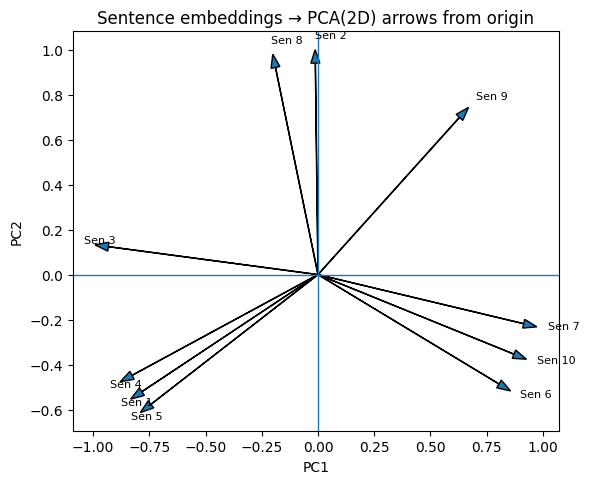

Sentence 1: Land use and land cover change detection and prediction in Bhutan's high altitude city of Thimphu, using cellular automata and Markov chain
Sentence 2: Rapid urbanization is changing landscapes often resulting in the degradation of ecosystem services and quality of urban life.
Sentence 3: Remote sensing and GIS tools can provide valuable information to deepen our understanding of the dynamics of these changes to better plan and build sustainable cities for the future.
Sentence 4: Using remote sensing data, socio-economic data, and field observations, we simulated spatiotemporal dynamics of land use and land cover changes in the city of Thimphu.
Sentence 5: Simulation results reveal that the landscape of Thimphu city has changed considerably during the study period and the change trend is predicted to continue into 2050.
Sentence 6: The study observed a significant increase (12.77%) in built-up area from 2002 (52.88%) to 2018 (65.5%), followed by a slight increase in the cov

In [27]:
plot_sentence_vectors_as_arrows(retrieval_system, max_vectors=10, which="sentence")
# Print the full text for the first max_vectors sentences
max_vectors = 10
for i in range(max_vectors):
    print(f"Sentence {i+1}: {retrieval_system.sentence_data[i]['text']}")


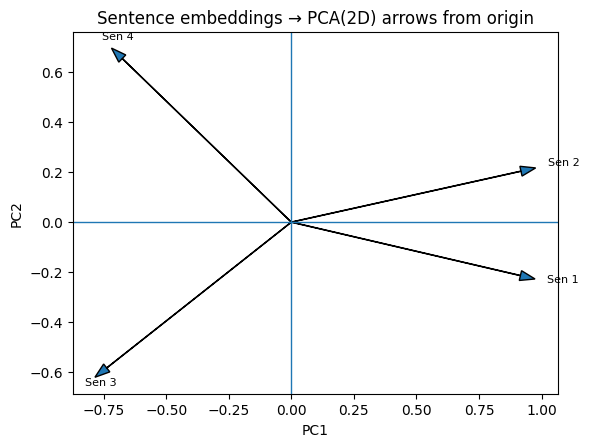

In [28]:
plot_sentence_vectors_as_arrows(retrieval_system, indices=[0, 3, 5, 9], which="sentence")



In [29]:
"""plot_sentence_vectors_as_arrows(retrieval_system, max_vectors=6, which="paragraph")"""


'plot_sentence_vectors_as_arrows(retrieval_system, max_vectors=6, which="paragraph")'

In [30]:
labeled_sentences_df = pd.read_csv('annotated_corpus_for_dataverse.csv')

# Filter for relevance_label 1 and 2 only
relevant_sentences_df = labeled_sentences_df[labeled_sentences_df['relevance_label'].isin([1, 2])]
relevant_sentences = relevant_sentences_df['text_segment'].tolist()
relevant_labels = relevant_sentences_df['relevance_label'].tolist()

# Use first 10 for demonstration
queries_to_process = relevant_sentences[:]
queries_labels = relevant_labels[:]

print(f"Processing {len(queries_to_process)} queries for chunk extraction...")



Processing 233 queries for chunk extraction...


In [32]:
"""queries_to_process = [
    "Assuming the dynamics recorded in the second period, the amounts of land covered by forest, woodland and tree savanna will decrease by 5, 9 and 17% of their cover in 1990, respectively, while the amount of degraded savanna and farmland will increase by 9 and 22% of the total area, respectively",
    
    "About 26 and 31% of the total area of natural vegetation (forest, woodland and tree savanna) will be converted to farmland and degraded savanna by 2050 if we assume the dynamics recorded from 1975 to 1990 and 1990-2010, respectively",
    
    "reported a moderate land cover change from 1965 to 2000 a decrease in savanna from 74% to 70% concurring with an expansion of cropland from 17% to 21%",
    
    "The major LULC changes in LCB from 1975 to 2013 stated by were the transition of water bodies and wetland around the Lake to cropland the loss of water bodies to other vegetation and an increase in urban area at the expense of other vegetation",
    
    "In Fakara the landscape was converted from a Sahelian savanna to largely eroded agricultural agroforestry parkland during the 20th century"
]

queries_labels = [2, 2, 2, 2, 2] """

'queries_to_process = [\n    "Assuming the dynamics recorded in the second period, the amounts of land covered by forest, woodland and tree savanna will decrease by 5, 9 and 17% of their cover in 1990, respectively, while the amount of degraded savanna and farmland will increase by 9 and 22% of the total area, respectively",\n    \n    "About 26 and 31% of the total area of natural vegetation (forest, woodland and tree savanna) will be converted to farmland and degraded savanna by 2050 if we assume the dynamics recorded from 1975 to 1990 and 1990-2010, respectively",\n    \n    "reported a moderate land cover change from 1965 to 2000 a decrease in savanna from 74% to 70% concurring with an expansion of cropland from 17% to 21%",\n    \n    "The major LULC changes in LCB from 1975 to 2013 stated by were the transition of water bodies and wetland around the Lake to cropland the loss of water bodies to other vegetation and an increase in urban area at the expense of other vegetation",\n  

In [33]:
# ## 8. Example: Single Query with Multi-Level Search
# Demonstrate multi-level search with one query
example_query = queries_to_process[0]
print(f"Example query: {example_query[:100]}...")

# Search at all levels
multi_results = retrieval_system.search_multi_level(example_query, top_k=5)

print(f"\n{'='*80}")
print("MULTI-LEVEL SEARCH RESULTS")
print(f"{'='*80}")

for level, results in multi_results.items():
    print(f"\nTop 3 {level.upper()}:")
    print("-" * 40)
    for i, result in enumerate(results[:3]):
        print(f"{i+1}. Score: {result['similarity_score']:.4f}")
        print(f"   Paper: {result['title']}")
        
        # Use 'section_name' instead of 'sections'
        print(f"   Section: {result['section_name']}")
        
        # Optional: Show unique ID for better tracking
        print(f"   Unique ID: {result['unique_id']}")
        
        # Show chunk type and original chunk index
        print(f"   Chunk Type: {result['chunk_type']}")
        print(f"   Chunk Index: {result['chunk_idx']}")
        
        print(f"   Text: {result['text'][:]}")
        print()


Example query: #text': 'After the droughts in the 1970s and 1980s, the observed loss of woody vegetation cover was ...

MULTI-LEVEL SEARCH RESULTS

Top 3 SENTENCES:
----------------------------------------
1. Score: 0.6325
   Paper: Vegetation Trends, Drought Severity and Land Use-Land Cover Change during the Growing Season in Semi-Arid Contexts
   Section: title
   Unique ID: sent_700
   Chunk Type: sentence
   Chunk Index: 0
   Text: Vegetation Trends, Drought Severity and Land Use-Land Cover Change during the Growing Season in Semi-Arid Contexts

2. Score: 0.6044
   Paper: Urban sprawl and its impact on land use land cover dynamics of Sekondi-Takoradi metropolitan assembly, Ghana
   Section: content
   Unique ID: sent_7296
   Chunk Type: sentence
   Chunk Index: 29
   Text: Vegetation and bare lands, however, decreased throughout the years.

3. Score: 0.6041
   Paper: Annual emissions of carbon from land use, land-use change, and forestry from 1850 to 2020
   Section: content
   Uni

KeyError: 'section_name'

In [34]:
if 'sentences' in multi_results and multi_results['sentences']:
    best_sentence = multi_results['sentences'][1]
    context_info = retrieval_system.get_context_for_chunk(best_sentence, context_window=2)
    
    print(f"{'='*80}")
    print("CONTEXT FOR BEST MATCHING SENTENCE")
    print(f"{'='*80}")
    print(f"Paper: {context_info['paper_title']}")
    print(f"Section: {context_info['sections_name']}")
    print(f"\nContext with surrounding sentences:")
    
    for i, sent in enumerate(context_info['context_sentences']):
        if i == context_info['target_sentence_idx']:
            print(f">>> TARGET: {sent}")
        else:
            print(f"    {sent}")

CONTEXT FOR BEST MATCHING SENTENCE
Paper: Urban sprawl and its impact on land use land cover dynamics of Sekondi-Takoradi metropolitan assembly, Ghana


KeyError: 'sections_name'

In [31]:
print(f"\n{'='*80}")
print("BATCH PROCESSING - SENTENCE EXTRACTION")
print(f"{'='*80}")

sentence_results = retrieval_system.batch_search_with_extraction(
    queries_to_process , 
    queries_labels , 
    top_k=7, 
    chunk_type='sentence'
)



BATCH PROCESSING - SENTENCE EXTRACTION
Processing 233 queries with sentence extraction...
Processing query 1/233
Processing query 2/233
Processing query 3/233
Processing query 4/233
Processing query 5/233
Processing query 6/233
Processing query 7/233
Processing query 8/233
Processing query 9/233
Processing query 10/233
Processing query 11/233
Processing query 12/233
Processing query 13/233
Processing query 14/233
Processing query 15/233
Processing query 16/233
Processing query 17/233
Processing query 18/233
Processing query 19/233
Processing query 20/233
Processing query 21/233
Processing query 22/233
Processing query 23/233
Processing query 24/233
Processing query 25/233
Processing query 26/233
Processing query 27/233
Processing query 28/233
Processing query 29/233
Processing query 30/233
Processing query 31/233
Processing query 32/233
Processing query 33/233
Processing query 34/233
Processing query 35/233
Processing query 36/233
Processing query 37/233
Processing query 38/233
Proces

In [32]:

# Display results for first query
first_query_key = list(sentence_results.keys())[0]
first_results = sentence_results[first_query_key]

print(f"Query: {first_results['query_text'][:100]}...")
print(f"Label: {first_results.get('relevance_label', 'N/A')}")
print(f"\nTop 5 Most Relevant Sentences:")

for result in first_results['results'][:5]:
    print(f"\nRank {result['rank']}:")
    print(f"  Score: {result['similarity_score']:.4f}")
    print(f"  Paper: {result['title']}")
    print(f"  Section: {result['section_name']}")
    print(f"  Sentence: {result['text']}")
    print("-" * 60)


Query: #text': 'After the droughts in the 1970s and 1980s, the observed loss of woody vegetation cover was ...
Label: 2

Top 5 Most Relevant Sentences:

Rank 1:
  Score: 0.6325
  Paper: Vegetation Trends, Drought Severity and Land Use-Land Cover Change during the Growing Season in Semi-Arid Contexts
  Section: title
  Sentence: Vegetation Trends, Drought Severity and Land Use-Land Cover Change during the Growing Season in Semi-Arid Contexts
------------------------------------------------------------

Rank 2:
  Score: 0.6044
  Paper: Urban sprawl and its impact on land use land cover dynamics of Sekondi-Takoradi metropolitan assembly, Ghana
  Section: content
  Sentence: Vegetation and bare lands, however, decreased throughout the years.
------------------------------------------------------------

Rank 3:
  Score: 0.6041
  Paper: Annual emissions of carbon from land use, land-use change, and forestry from 1850 to 2020
  Section: content
  Sentence: In this interpretation, labeled degr

In [33]:

"""

print(f"\n{'='*80}")
print("BATCH PROCESSING - PARAGRAPH EXTRACTION")
print(f"{'='*80}")

paragraph_results = retrieval_system.batch_search_with_extraction(
    queries_to_process, 
    queries_labels, 
    top_k=5, 
    chunk_type='paragraph'
)

# Display paragraph results for first query
first_para_results = paragraph_results[first_query_key]

print(f"Top 3 Most Relevant Paragraphs for: {first_para_results['query_text'][:100]}...")

for result in first_para_results['results'][:3]:
    print(f"\nRank {result['rank']}:")
    print(f"  Score: {result['similarity_score']:.4f}")
    print(f"  Paper: {result['title']}")
    print(f"  Section: {result['section_name']}")
    print(f"  Paragraph: {result['text'][:300]}...")
    print("-" * 60)
"""

'\n\nprint(f"\n{\'=\'*80}")\nprint("BATCH PROCESSING - PARAGRAPH EXTRACTION")\nprint(f"{\'=\'*80}")\n\nparagraph_results = retrieval_system.batch_search_with_extraction(\n    queries_to_process, \n    queries_labels, \n    top_k=5, \n    chunk_type=\'paragraph\'\n)\n\n# Display paragraph results for first query\nfirst_para_results = paragraph_results[first_query_key]\n\nprint(f"Top 3 Most Relevant Paragraphs for: {first_para_results[\'query_text\'][:100]}...")\n\nfor result in first_para_results[\'results\'][:3]:\n    print(f"\nRank {result[\'rank\']}:")\n    print(f"  Score: {result[\'similarity_score\']:.4f}")\n    print(f"  Paper: {result[\'title\']}")\n    print(f"  Section: {result[\'section_name\']}")\n    print(f"  Paragraph: {result[\'text\'][:300]}...")\n    print("-" * 60)\n'

In [34]:
 ## 12. Save Results

# Save sentence-level results
sentence_output_file = "sentence_extraction_results.csv"
sentence_df = retrieval_system.save_extraction_results(
    sentence_results, 
    sentence_output_file, 
    'sentence'
)



Extraction results saved to: sentence_extraction_results.csv


In [ ]:
# Save paragraph-level results
paragraph_output_file = "paragraph_extraction_results.csv"
paragraph_df = retrieval_system.save_extraction_results(
    paragraph_results, 
    paragraph_output_file, 
    'paragraph'
)

In [35]:

print(f"\n{'='*80}")
print("ANALYSIS: SENTENCE vs PARAGRAPH EXTRACTION")
print(f"{'='*80}")

print(f"Sentence-level results:")
print(f"  Total sentence chunks extracted: {len(sentence_df)}")
print(f"  Average similarity score: {sentence_df['similarity_score'].mean():.4f}")
print(f"  Max similarity score: {sentence_df['similarity_score'].max():.4f}")
print(f"  Average chunk length: {sentence_df['chunk_length'].mean():.0f} characters")

print(f"\nParagraph-level results:")
print(f"  Total paragraph chunks extracted: {len(paragraph_df)}")
print(f"  Average similarity score: {paragraph_df['similarity_score'].mean():.4f}")
print(f"  Max similarity score: {paragraph_df['similarity_score'].max():.4f}")
print(f"  Average chunk length: {paragraph_df['chunk_length'].mean():.0f} characters")

# Comparison by section
print(f"\nDistribution by paper section:")
print("Sentences:")
print(sentence_df['sections_name'].value_counts())
print("\nParagraphs:")
print(paragraph_df['sections_name'].value_counts())



ANALYSIS: SENTENCE vs PARAGRAPH EXTRACTION
Sentence-level results:
  Total sentence chunks extracted: 1631
  Average similarity score: 0.5988
  Max similarity score: 0.8514
  Average chunk length: 186 characters

Paragraph-level results:


NameError: name 'paragraph_df' is not defined

In [ ]:
if 'sentence_df' in locals():
    sentence_lengths = sentence_df['chunk_length'].tolist()
    print(f"From saved CSV results:")
    print(f"  Total sentences analyzed: {len(sentence_lengths)}")
    print(f"  Average sentence length: {np.mean(sentence_lengths):.2f} characters")
    print(f"  Median sentence length: {np.median(sentence_lengths):.2f} characters")
    print(f"  Min sentence length: {min(sentence_lengths)} characters")
    print(f"  Max sentence length: {max(sentence_lengths)} characters")
    print(f"  Standard deviation: {np.std(sentence_lengths):.2f} characters")

# Method 2: Calculate lengths directly from the retrieval system's sentence data
if hasattr(retrieval_system, 'sentence_data') and retrieval_system.sentence_data:
    direct_lengths = [len(item['text']) for item in retrieval_system.sentence_data]
    print(f"\nFrom all extracted sentences in memory:")
    print(f"  Total sentences in dataset: {len(direct_lengths)}")
    print(f"  Average sentence length: {np.mean(direct_lengths):.2f} characters")
    print(f"  Median sentence length: {np.median(direct_lengths):.2f} characters")
    print(f"  Min sentence length: {min(direct_lengths)} characters")
    print(f"  Max sentence length: {max(direct_lengths)} characters")
    print(f"  Standard deviation: {np.std(direct_lengths):.2f} characters")
    
    # Length distribution by percentiles
    print(f"\nLength distribution (percentiles):")
    percentiles = [10, 25, 50, 75, 90, 95, 99]
    for p in percentiles:
        print(f"  {p}th percentile: {np.percentile(direct_lengths, p):.0f} characters")


In [ ]:
# Complete example of using Label Studio converter with your retrieval system

# Step 1: Run your retrieval system and get results
print("Step 1: Getting retrieval results...")

# Example queries (replace with your actual queries)
queries_to_process = [
    "machine learning algorithms for text classification",
    "deep neural networks for image recognition", 
    "natural language processing techniques",
    "computer vision applications in healthcare",
    "reinforcement learning for robotics"
]

# Run batch search (replace with your actual retrieval results)
retrieval_results = retrieval_system.batch_search_with_extraction(
    queries_to_process, 
    top_k=10, 
    chunk_type='sentence'  # or 'paragraph', 'multi', etc.
)

print(f"Retrieved results for {len(queries_to_process)} queries")

# Step 2: Convert to Label Studio format
print("\nStep 2: Converting to Label Studio format...")

from label_studio_converter import LabelStudioConverter, prepare_label_studio_project

# Option A: Use the complete pipeline
label_tasks, config_xml = prepare_label_studio_project(
    retrieval_results,
    project_name="ScientificPaper_Retrieval_Evaluation",
    max_results_per_query=5  # Limit to top 5 results per query for manageable annotation
)

# Option B: Manual conversion with more control
converter = LabelStudioConverter()

# Convert results
label_tasks = converter.convert_results_to_label_studio(
    retrieval_results,
    output_file="retrieval_evaluation_tasks.json",
    max_results_per_query=5
)

# Save configuration
config_xml = converter.get_label_config_xml()
with open("retrieval_evaluation_config.xml", 'w', encoding='utf-8') as f:
    f.write(config_xml)

# Step 3: Show statistics about the created tasks
print(f"\n{'='*60}")
print("LABEL STUDIO TASKS SUMMARY")
print(f"{'='*60}")

# Count tasks by query
query_counts = {}
rank_counts = {}
similarity_ranges = {"high": 0, "medium": 0, "low": 0}

for task in label_tasks:
    # Count by query
    query_id = task['data']['query_id']
    query_counts[query_id] = query_counts.get(query_id, 0) + 1
    
    # Count by rank
    rank = task['data']['rank']
    rank_counts[rank] = rank_counts.get(rank, 0) + 1
    
    # Count by similarity score ranges
    sim_score = float(task['data']['similarity_score'])
    if sim_score >= 0.8:
        similarity_ranges["high"] += 1
    elif sim_score >= 0.5:
        similarity_ranges["medium"] += 1
    else:
        similarity_ranges["low"] += 1

print(f"Total tasks: {len(label_tasks)}")
print(f"Queries: {len(query_counts)}")
print(f"Tasks per query: {list(query_counts.values())}")
print(f"Rank distribution: {dict(sorted(rank_counts.items()))}")
print(f"Similarity ranges: {similarity_ranges}")

# Step 4: Show sample tasks for preview
print(f"\n{'='*60}")
print("SAMPLE TASKS PREVIEW")
print(f"{'='*60}")

for i, task in enumerate(label_tasks[:3]):  # Show first 3 tasks
    data = task['data']
    print(f"\nTask {i+1}:")
    print(f"  Query: {data['query_text'][:80]}...")
    print(f"  Rank: {data['rank']} | Score: {data['similarity_score']}")
    print(f"  Paper: {data['paper_title'][:60]}...")
    print(f"  Section: {data['section_name']} | Type: {data['chunk_type']}")
    print(f"  Chunk: {data['chunk_text'][:100]}...")
    print(f"  Unique ID: {data['unique_id']}")

# Step 5: Create a quick quality check
print(f"\n{'='*60}")
print("QUALITY CHECKS")
print(f"{'='*60}")

# Check for very short chunks that might be poor quality
short_chunks = [task for task in label_tasks if len(task['data']['chunk_text']) < 50]
print(f"Tasks with very short chunks (<50 chars): {len(short_chunks)}")

# Check for very low similarity scores
low_similarity = [task for task in label_tasks if float(task['data']['similarity_score']) < 0.3]
print(f"Tasks with low similarity (<0.3): {len(low_similarity)}")

# Check for duplicate chunks (shouldn't happen with fixed deduplication)
chunk_texts = [task['data']['chunk_text'] for task in label_tasks]
unique_chunks = set(chunk_texts)
print(f"Unique chunks: {len(unique_chunks)} / {len(chunk_texts)} total")

if len(unique_chunks) < len(chunk_texts):
    print("⚠️  Warning: Found duplicate chunks in Label Studio tasks!")
else:
    print("✅ No duplicate chunks found - good!")

# Step 6: Instructions for Label Studio setup
print(f"\n{'='*60}")
print("LABEL STUDIO SETUP INSTRUCTIONS")
print(f"{'='*60}")
print("""
1. Install Label Studio:
   pip install label-studio

2. Start Label Studio:
   label-studio start

3. Create a new project:
   - Go to http://localhost:8080
   - Click "Create Project"
   - Name: "Scientific Paper Retrieval Evaluation"

4. Configure the labeling interface:
   - Go to Settings > Labeling Interface
   - Click "Code" and paste the XML from 'retrieval_evaluation_config.xml'
   - Save

5. Import data:
   - Go to Data Manager
   - Click "Import"
   - Upload 'retrieval_evaluation_tasks.json'

6. Start labeling:
   - Each task shows a query and retrieved chunk
   - Classify as "Correct", "Not Correct", or "Partially Correct"
   - Add notes if needed
   - Rate quality (optional)

7. Export results:
   - After labeling, go to Export
   - Choose JSON format to get annotations
""")

# Step 7: Sample evaluation after labeling (for when you have annotations)
print(f"\n{'='*60}")
print("POST-LABELING ANALYSIS (Example)")
print(f"{'='*60}")
print("""
After you complete labeling in Label Studio, export the annotations and run:

# Load your exported annotations
with open('exported_annotations.json', 'r') as f:
    labeled_data = json.load(f)

# Generate evaluation summary
converter = LabelStudioConverter()
evaluation_summary = converter.create_evaluation_summary_from_labels(labeled_data)

# Print results
print("Evaluation Results:")
print(f"Overall Accuracy: {evaluation_summary['overall_performance']['accuracy']:.2%}")
print(f"Accuracy by Rank: {evaluation_summary['performance_by_rank']}")
print(f"Accuracy by Similarity: {evaluation_summary['performance_by_similarity']}")
""")

print(f"\n{'='*60}")
print("FILES CREATED:")
print("📁 ScientificPaper_Retrieval_Evaluation_tasks.json - Import this to Label Studio")
print("📁 ScientificPaper_Retrieval_Evaluation_config.xml - Use this for labeling interface")
print("📁 retrieval_evaluation_tasks.json - Alternative tasks file")  
print("📁 retrieval_evaluation_config.xml - Alternative config file")
print(f"{'='*60}")